In [1]:
import pandas as pd
from pathlib import Path

# Load the DataCo dataset (encoding='latin1' is required)
df = pd.read_csv("../data/DataCoSupplyChainDataset.csv", encoding='latin1')

print(f"Shape: {df.shape}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (180519, 53)

First 3 rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


In [2]:
# Check data types and missing values
print("=== Data Types ===")
print(df.dtypes.value_counts())
print("\n=== Missing Values (top 15) ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({"Missing": missing, "Pct": missing_pct}).sort_values("Missing", ascending=False)
print(missing_df.head(15))

=== Data Types ===
object     24
float64    15
int64      14
Name: count, dtype: int64

=== Missing Values (top 15) ===
                               Missing         Pct
Product Description             180519  100.000000
Order Zipcode                   155679   86.239676
Customer Lname                       8    0.004432
Customer Zipcode                     3    0.001662
Days for shipment (scheduled)        0    0.000000
Sales per customer                   0    0.000000
Benefit per order                    0    0.000000
Delivery Status                      0    0.000000
Late_delivery_risk                   0    0.000000
Customer City                        0    0.000000
Customer Country                     0    0.000000
Category Id                          0    0.000000
Category Name                        0    0.000000
Customer Fname                       0    0.000000
Customer Email                       0    0.000000


In [3]:
from pathlib import Path

csv_path = Path("../data/DataCoSupplyChainDataset.csv")
print("CSV exists?", csv_path.exists())

CSV exists? True


In [4]:
# Display summary statistics for a dataframe
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [5]:
df.dtypes

Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         float64
Longitude                        float64
Market          

In [6]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))


We have 29 numerical features : ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id', 'Latitude', 'Longitude', 'Order Customer Id', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Price', 'Product Status']

We have 24 categorical features : ['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Region', 'Order State', 'Orde

In [7]:
categorical_columns = []
for i in categorical_features:
    print(f'{i}: {len(df[i].unique())}')
    if len(df[i].unique()) < 10:
        categorical_columns.append(i)
        

Type: 4
Delivery Status: 4
Category Name: 50
Customer City: 563
Customer Country: 2
Customer Email: 1
Customer Fname: 782
Customer Lname: 1110
Customer Password: 1
Customer Segment: 3
Customer State: 46
Customer Street: 7458
Department Name: 11
Market: 5
Order City: 3597
Order Country: 164
order date (DateOrders): 65752
Order Region: 23
Order State: 1089
Order Status: 9
Product Image: 118
Product Name: 118
shipping date (DateOrders): 63701
Shipping Mode: 4


In [8]:
categorical_columns

['Type',
 'Delivery Status',
 'Customer Country',
 'Customer Email',
 'Customer Password',
 'Customer Segment',
 'Market',
 'Order Status',
 'Shipping Mode']

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

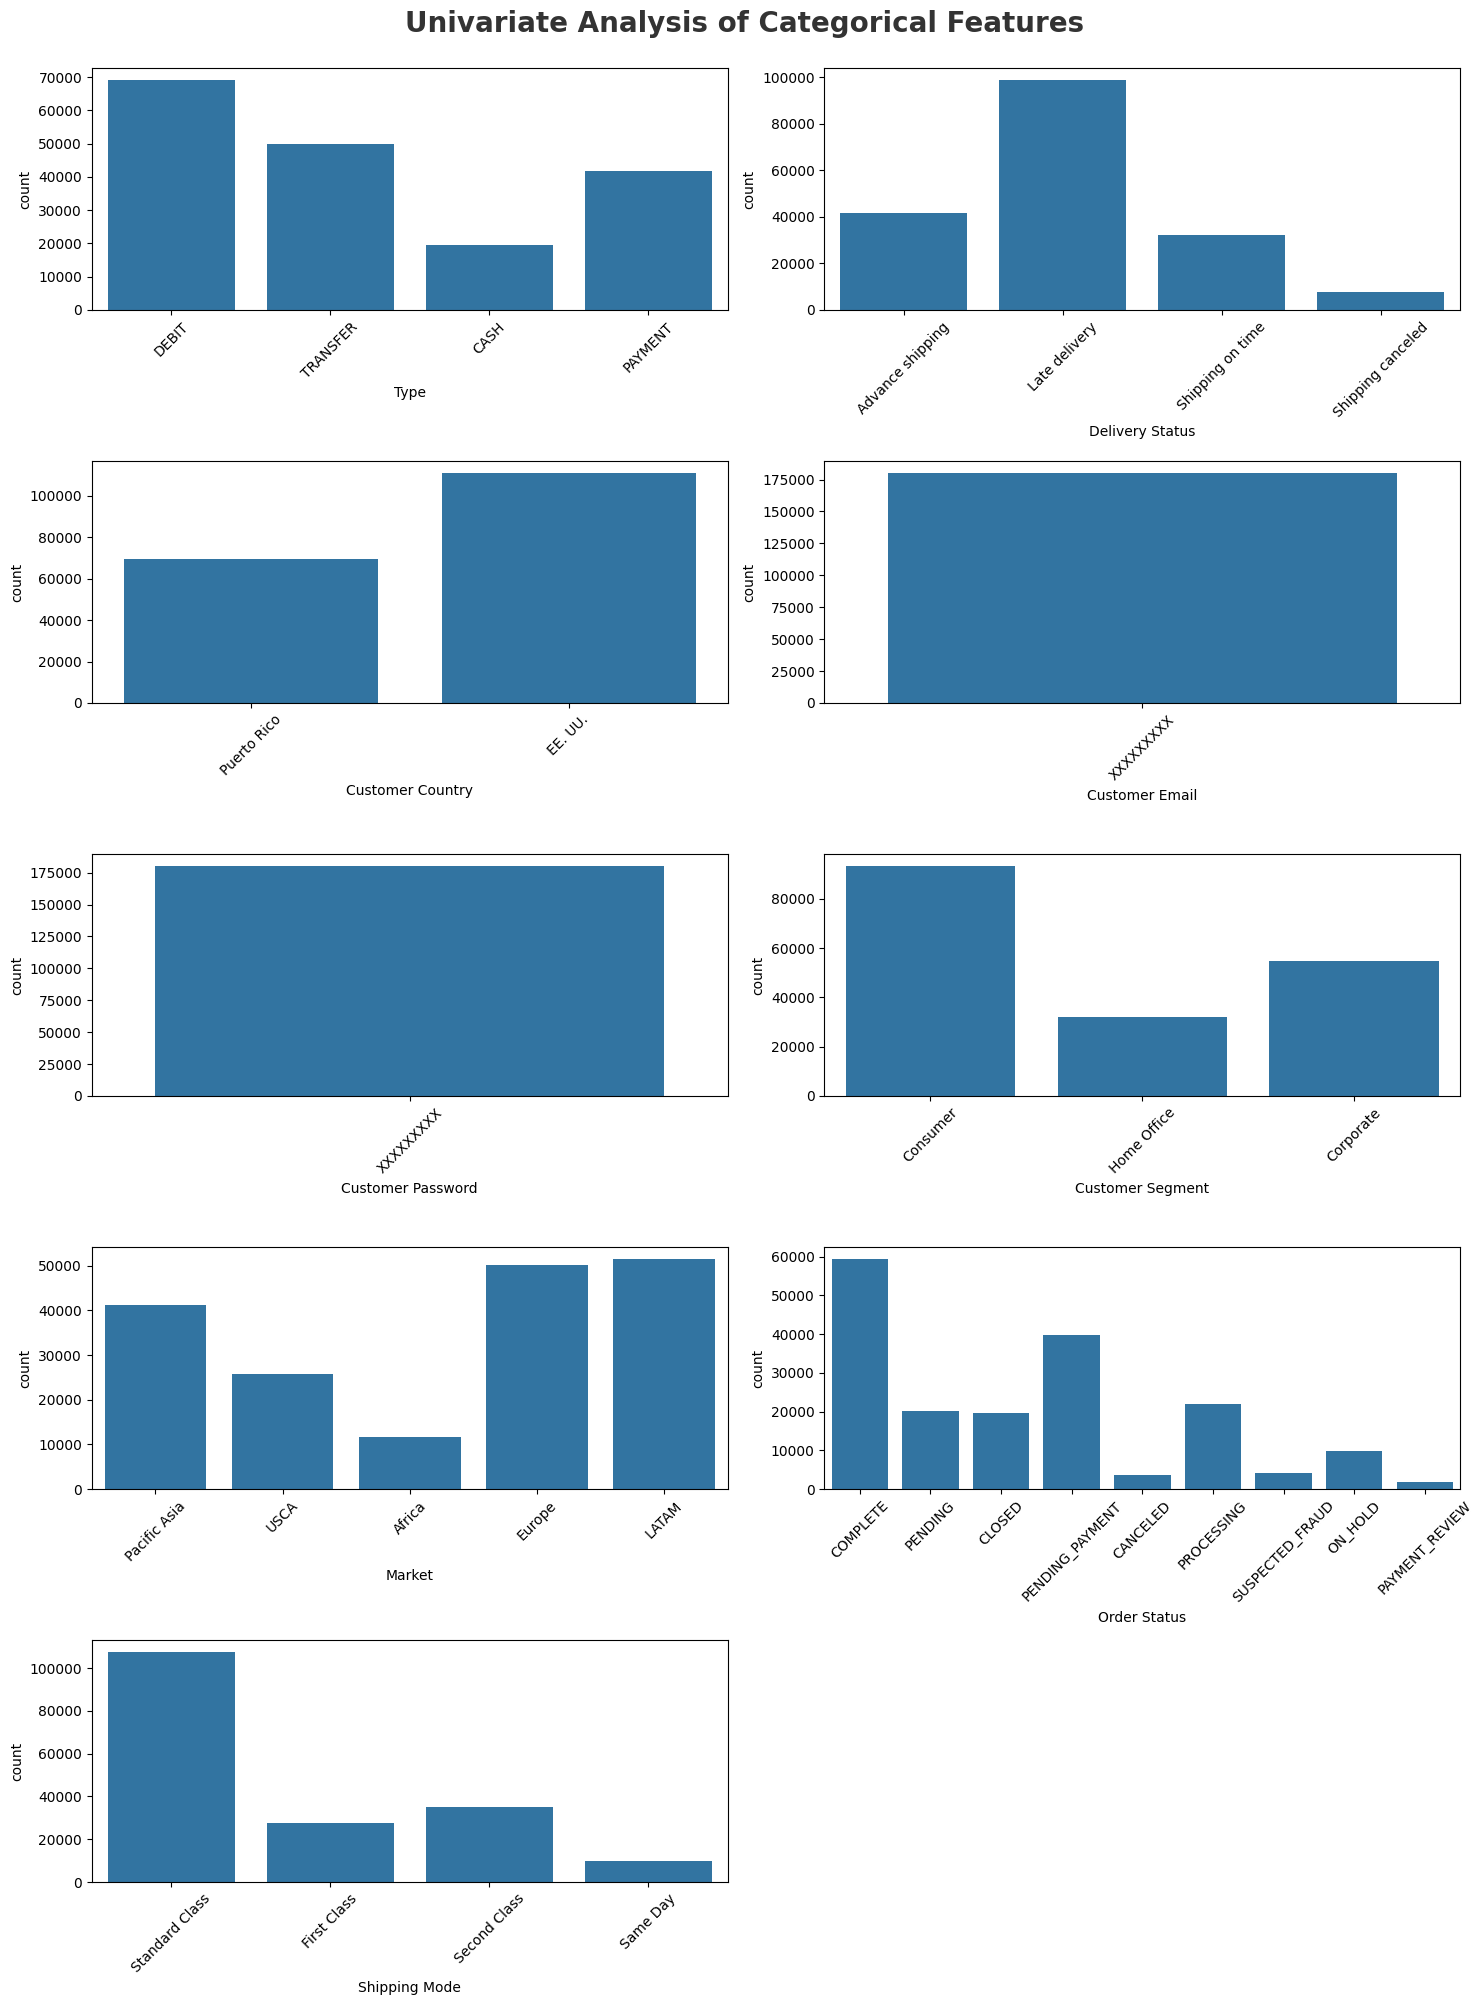

In [ ]:
# categorical columns
plt.figure(figsize=(15, 20))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

# Calculate how many rows we need based on the number of categorical columns
# Using ceil to round up to ensure we have enough space
import math
n_rows = math.ceil(len(categorical_columns) / 2)

for i in range(0, len(categorical_columns)):
    plt.subplot(n_rows, 2, i+1)  # Dynamically calculate rows needed
    sns.countplot(x=df[categorical_columns[i]])
    plt.xlabel(categorical_columns[i])
    plt.xticks(rotation=45)

plt.tight_layout()  # Moved outside the loop to apply once after all subplots

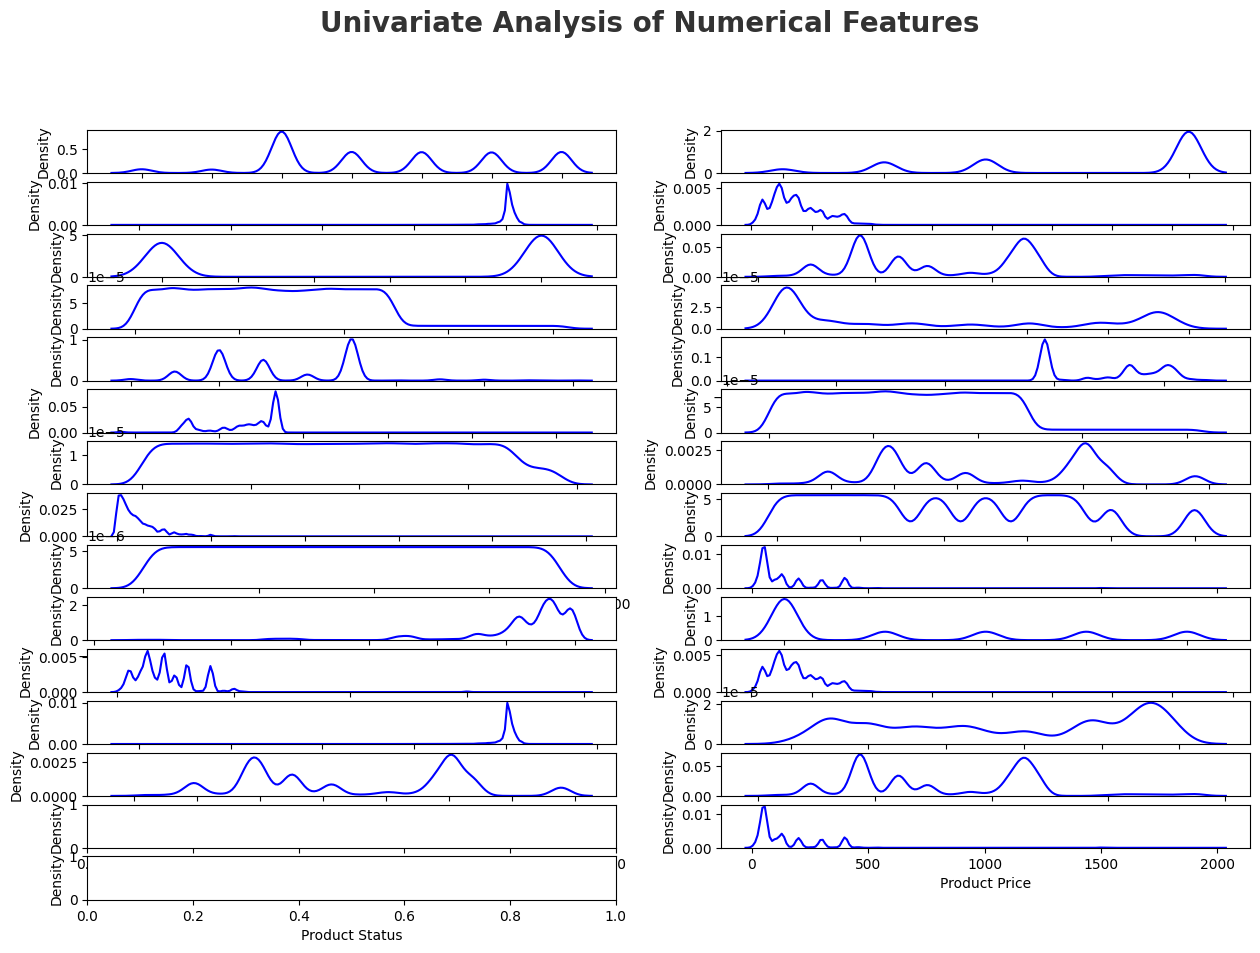

In [10]:
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

# Calculate how many rows we need based on the number of features
# This ensures we have enough subplots for all features
num_features = len(numeric_features)
num_cols = 2  # Keep 2 columns
num_rows = (num_features + 1) // 2  # Calculate rows needed, rounding up

for i in range(0, num_features):
    plt.subplot(num_rows, num_cols, i+1)  # Adjust grid size dynamically
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    plt.xlabel(numeric_features[i])
    
plt.tight_layout()  # Move tight_layout outside the loop

# Assistant
The error occurs because you're trying to create more subplots than the grid can accommodate. Your code is trying to create a 4x2 grid (which allows for 8 subplots), but you're attempting to plot more than 8 features.

The error happens when the loop index `i` reaches 8, making `i+1` equal to 9, which exceeds the maximum number of subplots (8) in your 4x2 grid.

Would you like me to provide the corrected code?

# User
yes

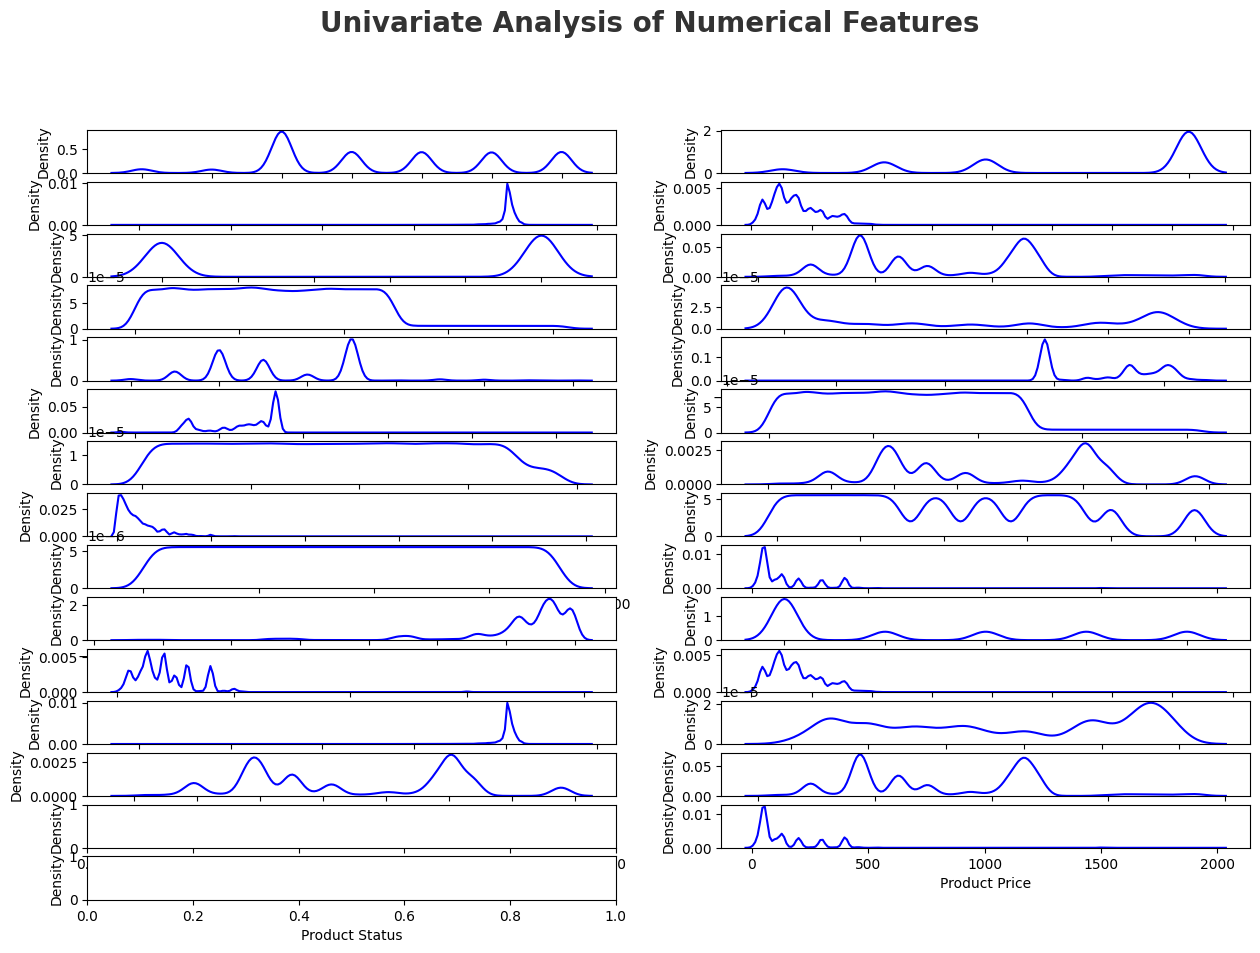

In [ ]:
plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

# Calculate how many rows we need based on the number of features
# Using 2 columns and math.ceil to round up for odd numbers of features
import math
rows = math.ceil(len(numeric_features) / 2)

for i in range(0, len(numeric_features)):
    plt.subplot(rows, 2, i+1)  # Dynamically calculate rows needed
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    plt.xlabel(numeric_features[i])
    
plt.tight_layout()  # Move tight_layout outside the loop

In [11]:
df.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [12]:
# Filter only numeric columns before calculating correlation
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols].corr()

# Alternatively, if you want to keep only numeric columns from your selection:
numeric_cols = [col for col in list(df.columns)[1:] if df[col].dtype in ['int64', 'float64']]
df[numeric_cols].corr()

# Remove this problematic line that includes non-numeric columns
# df[(list(df.columns)[1:])].corr()  

# If you still want to calculate correlation for columns after the first one,
# but only include numeric columns, use:
df[list(df.columns)[1:]].select_dtypes(include=['int64', 'float64']).corr()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
Days for shipping (real),1.000000,0.515880,-0.005101,0.001757,0.401415,-0.000348,0.003432,0.000112,-0.001631,-0.004073,...,-0.000811,0.001962,0.001757,-0.005101,-0.000811,-0.000859,-0.000348,NaN,0.002185,NaN
Days for shipment (scheduled),0.515880,1.000000,-0.000185,0.006445,-0.369352,-0.000367,0.000899,-0.003019,-0.000262,-0.005300,...,-0.002925,0.006327,0.006445,-0.000185,0.005249,-0.000431,-0.000367,NaN,0.006912,NaN
Benefit per order,-0.005101,-0.000185,1.000000,0.133484,-0.003727,0.031889,0.009354,0.002235,0.031442,0.000338,...,0.015696,0.131816,0.133484,1.000000,-0.004978,0.033161,0.031889,NaN,0.103459,NaN
Sales per customer,0.001757,0.006445,0.133484,1.000000,-0.003791,0.225201,0.060181,-0.001304,0.232367,-0.000223,...,0.105413,0.989744,1.000000,0.133484,-0.000138,0.236367,0.225201,NaN,0.781781,NaN
Late_delivery_risk,0.401415,-0.369352,-0.003727,-0.003791,1.000000,0.001752,0.001484,0.003148,0.001077,0.000679,...,-0.000139,-0.003564,-0.003791,-0.003727,-0.014131,0.001490,0.001752,NaN,-0.002175,NaN
Category Id,-0.000348,-0.000367,0.031889,0.225201,0.001752,1.000000,0.274633,0.002898,0.888835,0.002195,...,-0.302408,0.227483,0.225201,0.031889,-0.005943,0.991092,1.000000,NaN,0.461059,NaN
Customer Id,0.003432,0.000899,0.009354,0.060181,0.001484,0.274633,1.000000,0.002022,0.136897,0.002335,...,-0.091328,0.060961,0.060181,0.009354,-0.005659,0.228039,0.274633,NaN,0.111118,NaN
Customer Zipcode,0.000112,-0.003019,0.002235,-0.001304,0.003148,0.002898,0.002022,1.000000,0.002878,0.584553,...,-0.006174,-0.001490,-0.001304,0.002235,0.011843,0.003173,0.002898,NaN,0.002191,NaN
Department Id,-0.001631,-0.000262,0.031442,0.232367,0.001077,0.888835,0.136897,0.002878,1.000000,0.002460,...,-0.265437,0.234718,0.232367,0.031442,-0.005982,0.906117,0.888835,NaN,0.446743,NaN
Latitude,-0.004073,-0.005300,0.000338,-0.000223,0.000679,0.002195,0.002335,0.584553,0.002460,1.000000,...,-0.001853,-0.000696,-0.000223,0.000338,-0.002921,0.002031,0.002195,NaN,0.000471,NaN


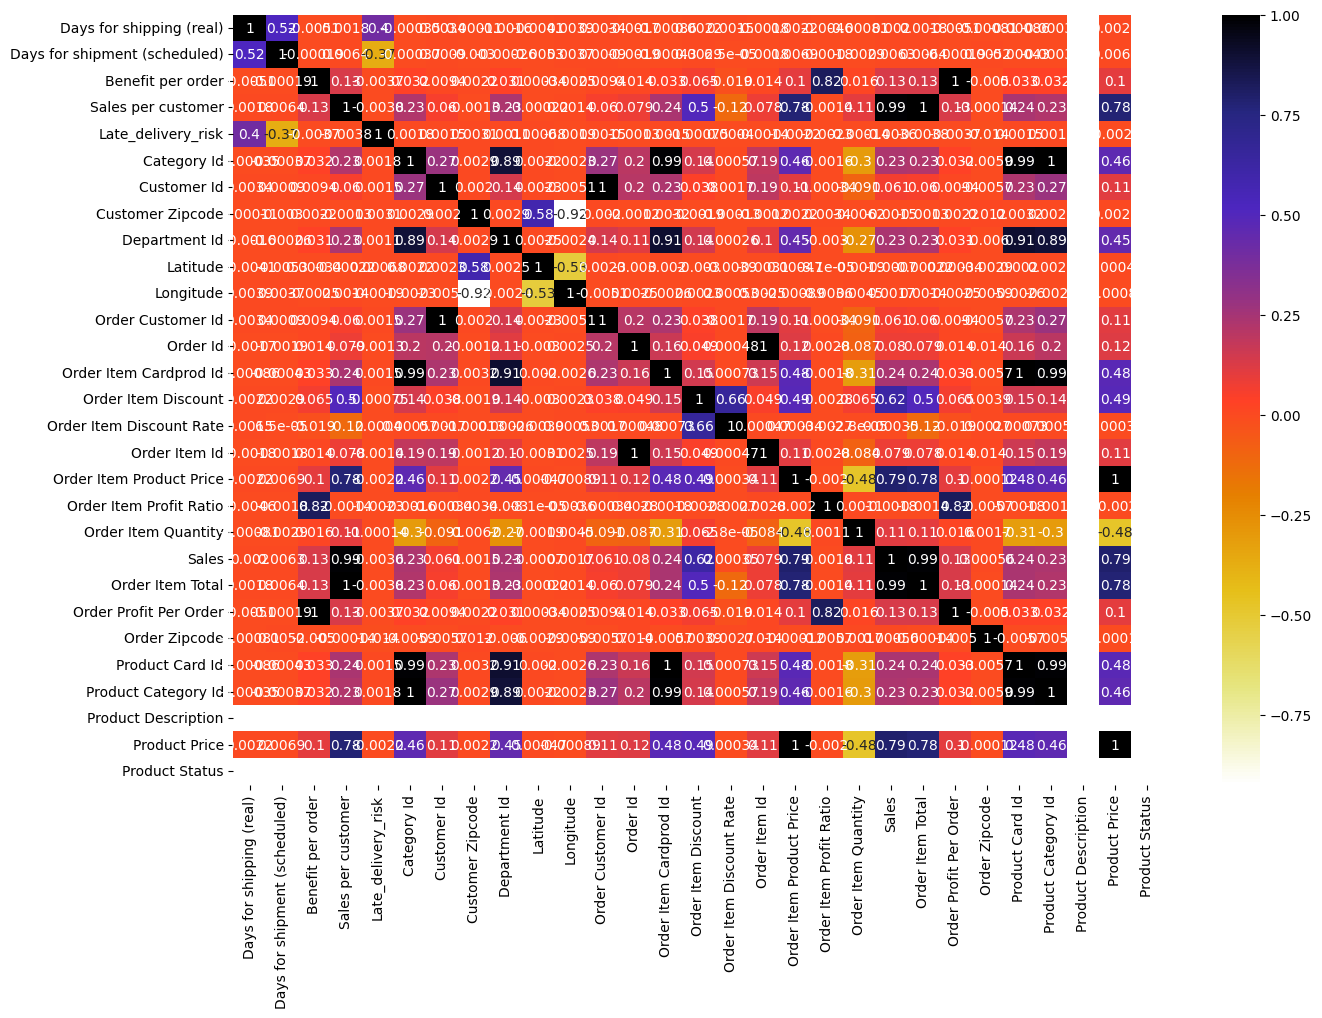

In [ ]:
# First, filter only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Now create the heatmap with only numeric columns
plt.figure(figsize=(15, 10))
sns.heatmap(numeric_df.corr(), cmap="CMRmap_r", annot=True)
plt.show()

# Alternatively, if you need to include the column with 'DEBIT' values,
# you might need to convert it to numeric values first:
# For example, if 'DEBIT' and 'CREDIT' are transaction types, you could map them:
# df['transaction_type'] = df['transaction_type'].map({'DEBIT': 0, 'CREDIT': 1})

NameError: name 'target_feature' is not defined

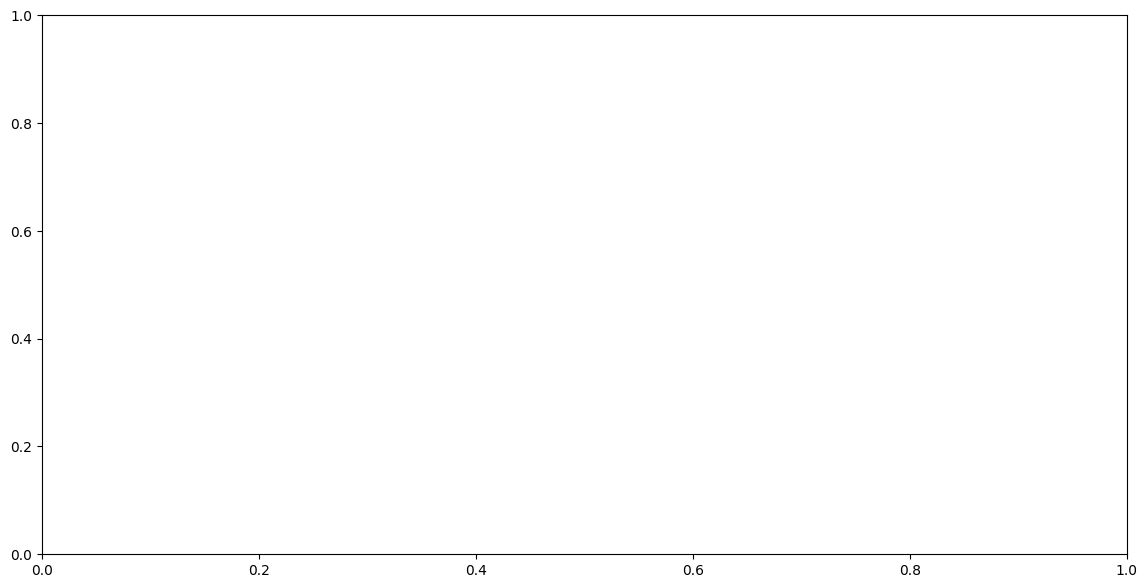

In [ ]:
plt.subplots(figsize=(14,7))
sns.histplot(df[target_feature], bins=200, kde=True, color = 'b')
plt.title("Cost Distribution", weight="bold",fontsize=20, pad=20)
plt.ylabel("Count", weight="bold", fontsize=12)
plt.xlabel("Cost price in millions", weight="bold", fontsize=12)
plt.xlim(-50000,300000)
plt.show()

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import json

# Target column
target = 'Sales per customer'

# Columns to drop (leakage, ID, constant, redundant, high-missing)
drop_cols = [
    # Leakage (future info)
    'Delivery Status', 'Late_delivery_risk',
    'shipping date (DateOrders)', 'order date (DateOrders)',
    # IDs
    'Order Id', 'Order Item Id', 'Product Card Id', 'Customer Id', 'Department Id',
    'Order Customer Id', 'Order Item Cardprod Id',
    # Constant / useless
    'Product Description', 'Product Image', 'Order Zipcode',
    'Customer Email', 'Customer Password', 'Product Status',
    # Redundant (highly correlated with target or duplicate)
    'Order Item Total', 'Sales'
]

# Numeric features to keep
numeric_features = [
    'Benefit per order',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Profit Ratio',
    'Order Item Quantity',
    'Product Price',
    'Days for shipping (real)',
    'Days for shipment (scheduled)'
]

# Categorical features to keep (low to moderate cardinality)
categorical_features = [
    'Type',
    'Category Name',
    'Customer Segment',
    'Market',
    'Order Region',
    'Shipping Mode'
]

# Build cleaned dataframe
keep_cols = numeric_features + categorical_features + [target]
df_clean = df[keep_cols].copy()

# Drop rows where target is missing (none here, but safe)
df_clean = df_clean.dropna(subset=[target])

# Impute numeric missing with median
for col in numeric_features:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Impute categorical missing with most frequent
for col in categorical_features:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)

print(f"Cleaned shape: {df_clean.shape}")
df_clean.head()

Cleaned shape: (180519, 16)


,Benefit per order,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Product Price,Days for shipping (real),Days for shipment (scheduled),Type,Category Name,Customer Segment,Market,Order Region,Shipping Mode,Sales per customer
0,91.250000,13.110000,0.04,327.75,0.29,1,327.75,3,4,DEBIT,Sporting Goods,Consumer,Pacific Asia,Southeast Asia,Standard Class,314.640015
1,-249.089996,16.389999,0.05,327.75,-0.80,1,327.75,5,4,TRANSFER,Sporting Goods,Consumer,Pacific Asia,South Asia,Standard Class,311.359985
2,-247.779999,18.030001,0.06,327.75,-0.80,1,327.75,4,4,CASH,Sporting Goods,Consumer,Pacific Asia,South Asia,Standard Class,309.720001
3,22.860001,22.940001,0.07,327.75,0.08,1,327.75,3,4,DEBIT,Sporting Goods,Home Office,Pacific Asia,Oceania,Standard Class,304.809998
4,134.210007,29.500000,0.09,327.75,0.45,1,327.75,2,4,PAYMENT,Sporting Goods,Corporate,Pacific Asia,Oceania,Standard Class,298.250000


In [14]:
# Separate features and target
X = df_clean.drop(columns=[target])
y = df_clean[target]

# First split: 70% train+val, 30% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Second split: from train+val, take 15/85 ≈ 0.1765 of the 70% to get 15% overall
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42
)

print(f"Train: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}")

Train: 104059 | Validation: 22304 | Test: 54156


In [ ]:
# Label encode categoricals for TabPFN
X_train_tab = X_train.copy()
X_val_tab = X_val.copy()
X_test_tab = X_test.copy()

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    # Fit on train only
    X_train_tab[col] = le.fit_transform(X_train_tab[col])
    # Transform val and test (handle unseen labels with a fallback)
    X_val_tab[col] = X_val_tab[col].map(lambda s: '<unknown>' if s not in le.classes_ else s)
    le.classes_ = np.append(le.classes_, '<unknown>')
    X_val_tab[col] = le.transform(X_val_tab[col])
    X_test_tab[col] = X_test_tab[col].map(lambda s: '<unknown>' if s not in le.classes_ else s)
    X_test_tab[col] = le.transform(X_test_tab[col])
    label_encoders[col] = le

# Scale numeric features
scaler = StandardScaler()
X_train_tab_scaled = scaler.fit_transform(X_train_tab)
X_val_tab_scaled = scaler.transform(X_val_tab)
X_test_tab_scaled = scaler.transform(X_test_tab)

print("TabPFN preprocessing complete.")

In [ ]:
from tabpfn import TabPFNRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

model_tab = TabPFNRegressor(device='cpu', n_estimators=32, random_state=42)

start = time.time()
model_tab.fit(X_train_tab_scaled, y_train)
train_time_tab = time.time() - start

y_pred_val_tab = model_tab.predict(X_val_tab_scaled)

rmse_tab = np.sqrt(mean_squared_error(y_val, y_pred_val_tab))
mae_tab = mean_absolute_error(y_val, y_pred_val_tab)
r2_tab = r2_score(y_val, y_pred_val_tab)

print(f"TabPFN Validation → RMSE: {rmse_tab:.4f} | MAE: {mae_tab:.4f} | R²: {r2_tab:.4f} | Time: {train_time_tab:.1f}s")